# ThreatLens AI — Notebook 01: Data Loading, EDA & Cleaning

**Dataset:** CICIDS2017 (Canadian Institute for Cybersecurity Intrusion Detection dataset)
**Stage in the pipeline:** `Security Logs → Ingestion → Validation → Cleaning`

### What this notebook does
1. Loads all 8 raw CICIDS2017 CSV files and merges them into one dataset
2. Explores the raw data *before* touching it — shape, dtypes, missing values, class balance
3. Cleans the data: fixes column names, handles infinite/missing values, removes duplicates, standardizes attack labels
4. Explores the data *after* cleaning, to confirm the cleaning actually worked
5. Saves one clean, merged file that every later notebook (anomaly detection, classification, forecasting) will build on

### Why this matters
Every model we build later is only as good as this notebook. If we skip proper cleaning here, problems like `Infinity` values or duplicate rows will silently corrupt every downstream model — including ones far more expensive to debug than this one. This is also why cleaning logic lives in `src/preprocessing/clean.py` as reusable, tested functions rather than one-off code pasted into a notebook cell: the exact same functions will run inside the FastAPI service later, so training and inference never drift apart.


## 1. Setup

We import pandas/numpy for data handling, matplotlib/seaborn for plots, and our own `src` modules for ingestion and cleaning. Because this notebook lives inside `notebooks/`, we add the project root to `sys.path` so `from src... import ...` works the same way it will inside the FastAPI app later.


In [7]:
import sys
from pathlib import Path

# Add project root to the path so `src` is importable from inside notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.ingestion.load_data import load_all_csvs
from src.preprocessing.clean import run_full_cleaning

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", RAW_DIR)


Project root: c:\Users\Microsoft\Desktop\Nayi_Manzil_Internship\ThreatLensAI
Raw data dir: c:\Users\Microsoft\Desktop\Nayi_Manzil_Internship\ThreatLensAI\data\raw


## 2. Load the raw data

`load_all_csvs()` scans `data/raw/` for the 8 expected CICIDS2017 files, reads each one, tags every row with which day/session it came from (`source_file`), and concatenates everything into a single DataFrame.

We deliberately do **not** clean anything in this step — loading and cleaning are kept separate so that if something looks wrong later, we can always tell whether the problem came from the raw files themselves or from something our cleaning code did.

> If this cell raises `FileNotFoundError`, it will tell you exactly which file(s) it expected but couldn't find — double check the filenames inside `data/raw/` match what you downloaded from Kaggle.


In [8]:
raw_df = load_all_csvs(RAW_DIR)
raw_df.head()

  loaded monday                       ->  529,918 rows, 80 cols  (Monday-WorkingHours.pcap_ISCX.csv)
  loaded tuesday                      ->  445,909 rows, 80 cols  (Tuesday-WorkingHours.pcap_ISCX.csv)
  loaded wednesday                    ->  692,703 rows, 80 cols  (Wednesday-workingHours.pcap_ISCX.csv)
  loaded thursday_morning             ->  170,366 rows, 80 cols  (Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv)
  loaded thursday_afternoon           ->  288,602 rows, 80 cols  (Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv)
  loaded friday_morning               ->  191,033 rows, 80 cols  (Friday-WorkingHours-Morning.pcap_ISCX.csv)
  loaded friday_afternoon_ddos        ->  225,745 rows, 80 cols  (Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv)
  loaded friday_afternoon_portscan    ->  286,467 rows, 80 cols  (Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv)

  TOTAL combined -> 2,830,743 rows, 80 cols


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,monday
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,monday
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,monday
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,monday
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,monday


## 3. Explore the raw data (before cleaning)

Before fixing anything, we look at the data exactly as it arrived. This gives us a baseline to compare against after cleaning, and it's how we *discover* the problems (infinite values, messy column names, duplicates) instead of just taking our word for it that they exist.


In [9]:
print(f"Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
print()
raw_df.info(verbose=False, memory_usage="deep")

Shape: 2,830,743 rows x 80 columns

<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Columns: 80 entries,  Destination Port to source_file
dtypes: float64(24), int64(54), str(2)
memory usage: 1.7 GB


Notice the column names above — CICIDS2017's raw headers have inconsistent leading spaces (e.g. `' Flow Duration'`). This is exactly what `clean_column_names()` will fix in the next section.

Next, let's check for missing values and infinite values directly, so we have real numbers (not just a description) of how big the problem is.


In [10]:
numeric_cols = raw_df.select_dtypes(include=[np.number]).columns

missing_counts = raw_df[numeric_cols].isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

inf_counts = np.isinf(raw_df[numeric_cols]).sum()
inf_counts = inf_counts[inf_counts > 0].sort_values(ascending=False)

print("Columns with missing (NaN) values:")
print(missing_counts if len(missing_counts) else "  none")
print()
print("Columns with infinite values:")
print(inf_counts if len(inf_counts) else "  none")

Columns with missing (NaN) values:
Flow Bytes/s    1358
dtype: int64

Columns with infinite values:
 Flow Packets/s    2867
Flow Bytes/s       1509
dtype: int64


### Raw class distribution

CICIDS2017 is known to be **heavily imbalanced** — most traffic is benign, and some attack types (like Heartbleed) have only a handful of examples in the entire dataset. Seeing this now, before cleaning, matters because class imbalance will directly shape which models and evaluation metrics make sense later (accuracy alone will be misleading — we'll lean on precision/recall/F1 per class instead).


 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


C:\Users\Microsoft\AppData\Local\Temp\ipykernel_544\3569607369.py:11: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Microsoft\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


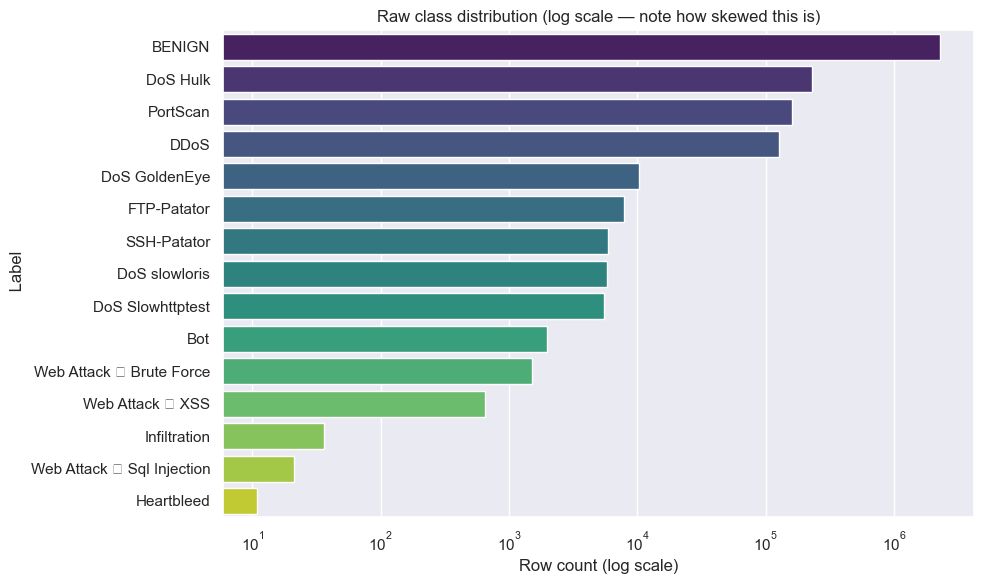

In [11]:
label_col = [c for c in raw_df.columns if c.strip().lower() == "label"][0]
raw_label_counts = raw_df[label_col].value_counts()

print(raw_label_counts)

plt.figure(figsize=(10, 6))
sns.barplot(y=raw_label_counts.index, x=raw_label_counts.values, hue=raw_label_counts.index, palette="viridis", legend=False)
plt.xscale("log")
plt.xlabel("Row count (log scale)")
plt.title("Raw class distribution (log scale — note how skewed this is)")
plt.tight_layout()
plt.show()

## 4. Clean the data

Now that we've *seen* the problems, we fix them. `run_full_cleaning()` runs four steps in order, and prints what it did at each step so nothing happens silently:

1. **Clean column names** — strip whitespace, lowercase, replace symbols with underscores
2. **Handle infinite/missing values** — replace `inf`/`-inf` with `NaN`, then drop rows still containing `NaN` in any numeric column (we drop rather than impute here, because guessing a value for a flow-rate feature would mean inventing network behavior that never actually happened)
3. **Remove duplicate rows** — CICIDS2017 has a documented duplicate-row issue that would otherwise inflate whichever class the duplicates belong to
4. **Standardize attack labels** — map CICIDS2017's raw label strings onto the 7-class attack taxonomy used across the ThreatLens AI project (see `attack_category` column)

**A transparency note on the label mapping** (see `LABEL_MAP` in `src/preprocessing/clean.py` for the full table): CICIDS2017 does not contain traffic literally labeled "Credential Stuffing" — the closest real match is `FTP-Patator`/`SSH-Patator` (brute-force login attempts), so those are mapped to **Brute Force**. `Bot` and `Infiltration` don't map cleanly onto the blueprint's 7 classes either, so they're kept as their own categories rather than forced into the wrong bucket — a mislabeled class would quietly poison every model trained on it.


In [12]:
clean_df = run_full_cleaning(raw_df, label_col=label_col.strip().lower())
print()
print(f"Final shape after cleaning: {clean_df.shape[0]:,} rows x {clean_df.shape[1]} columns")

Step 1/4 — cleaning column names
Step 2/4 — handling infinite / missing values
  dropped 2,867 rows containing inf/NaN in numeric columns (0.101% of data)
Step 3/4 — removing duplicate rows
  removed 255,236 duplicate rows (9.026% of data)
Step 4/4 — standardizing attack labels

Final shape after cleaning: 2,572,640 rows x 81 columns


## 5. Explore the cleaned data

Let's confirm the cleaning actually worked, and look at the class distribution again — now grouped into the `attack_category` taxonomy instead of CICIDS2017's raw, more granular labels.


In [13]:
assert clean_df.isna().sum().sum() == 0, "There should be zero missing values left after cleaning"
assert not np.isinf(clean_df.select_dtypes(include=[np.number])).any().any(), "There should be zero infinite values left"
assert clean_df.duplicated().sum() == 0, "There should be zero duplicate rows left"
print("All cleaning checks passed.")

All cleaning checks passed.


attack_category
Normal           2146899
DDoS              321759
Port Scanning      90694
Brute Force         9150
Web Attack          2143
Botnet              1948
Infiltration          36
Other                 11
Name: count, dtype: int64


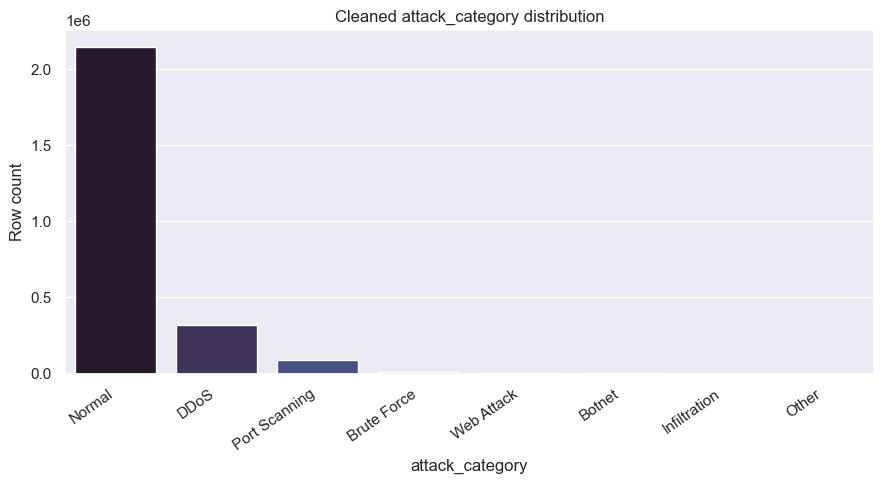

In [14]:
category_counts = clean_df["attack_category"].value_counts()
print(category_counts)

plt.figure(figsize=(9, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index, palette="mako", legend=False)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Row count")
plt.title("Cleaned attack_category distribution")
plt.tight_layout()
plt.show()

### A quick look at feature correlations

With 78 raw features, a full correlation heatmap is unreadable — instead we sample a manageable subset of the numeric columns most related to traffic volume and timing, which are usually the most informative for anomaly detection later. This is purely exploratory at this stage; formal feature selection happens in the next notebook.


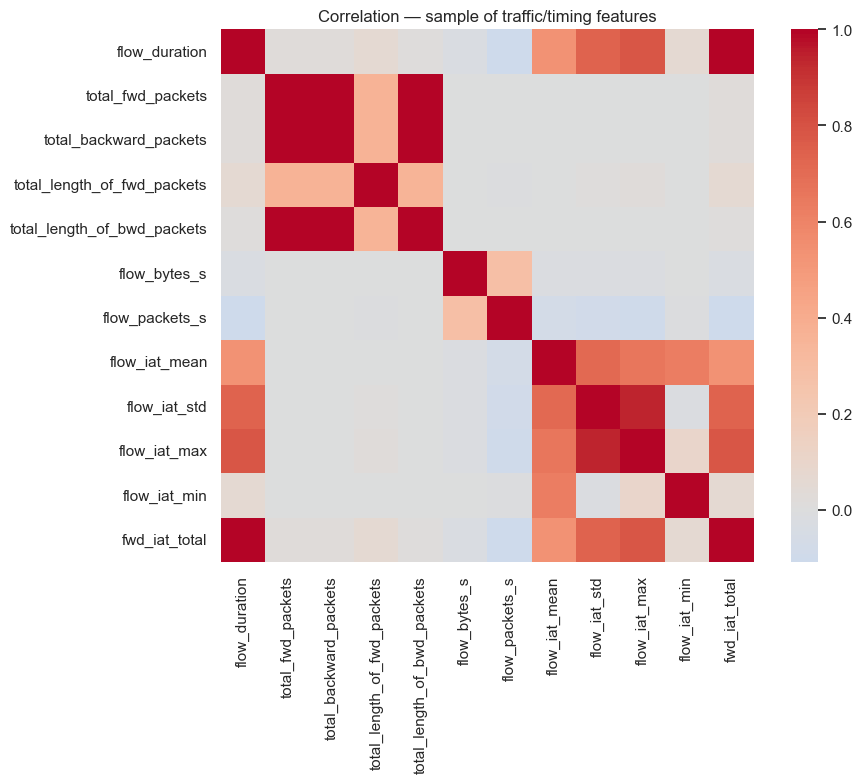

In [15]:
candidate_cols = [c for c in clean_df.columns if any(
    key in c for key in ["duration", "packets", "bytes", "iat", "flow"]
)][:12]

plt.figure(figsize=(10, 8))
corr = clean_df[candidate_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation — sample of traffic/timing features")
plt.tight_layout()
plt.show()

## 6. Save the cleaned dataset

We save as **Parquet**, not CSV. For a dataset this size (millions of rows, 78+ columns), Parquet is significantly smaller on disk and much faster to read back in later notebooks, and — unlike CSV — it preserves exact dtypes, so we don't have to re-guess column types every time we load it.

Every later notebook (`02_anomaly_detection`, `03_attack_classifier`, ...) will start by reading this one file instead of repeating the loading + cleaning steps above.


In [16]:
output_path = PROCESSED_DIR / "cicids2017_cleaned.parquet"
clean_df.to_parquet(output_path, index=False)
print(f"Saved cleaned dataset -> {output_path}")
print(f"File size: {output_path.stat().st_size / (1024**2):.1f} MB")

Saved cleaned dataset -> c:\Users\Microsoft\Desktop\Nayi_Manzil_Internship\ThreatLensAI\data\processed\cicids2017_cleaned.parquet
File size: 312.9 MB


## 7. Summary & next steps

| Step | Result |
|---|---|
| Raw rows loaded | see Section 2 output above |
| Rows dropped (inf/NaN) | see Section 4 output above |
| Duplicate rows removed | see Section 4 output above |
| Final clean row count | see Section 5 output above |
| Attack categories | Normal, Brute Force, DDoS, Port Scanning, Web Attack, Botnet, Infiltration, Other |
| Output file | `data/processed/cicids2017_cleaned.parquet` |

**Next notebook (`02_anomaly_detection.ipynb`)** will use this cleaned file to train and evaluate an Isolation Forest anomaly detector — the first AI engine in the ThreatLens AI architecture.
